In [62]:
!pip install faker


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [63]:
import pandas as pd
import numpy as np
import random
import os
import json

from faker import Faker
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
fake = Faker()

# Make results reproducible
random.seed(42)
np.random.seed(42)
Faker.seed(42)

In [65]:
os.makedirs("generated_data", exist_ok=True)
os.makedirs("charts", exist_ok=True)

In [66]:
NUM_CUSTOMERS = 5000
NUM_PRODUCTS = 800

NUM_ORDERS_DAY1 = 20000
NUM_ORDER_ITEMS_DAY1 = 55000

NUM_ORDERS_DAY2 = 4000
NUM_ORDER_ITEMS_DAY2 = 11000

NUM_CLICKSTREAM_DAY1 = 15000
NUM_CLICKSTREAM_DAY2 = 15000

In [67]:
customers = []

for i in range(NUM_CUSTOMERS):

    customer = {
        "customer_id": i + 1,
        "first_name": fake.first_name(),
        "last_name": fake.last_name(),
        "email": fake.email(),
        "phone": fake.phone_number(),
        "city": fake.city(),
        "state": fake.state(),
        "country": "India",
        "signup_date": fake.date_between(
            start_date="-3y",
            end_date="today"
        )
    }

    customers.append(customer)

customers_df = pd.DataFrame(customers)

In [68]:
num_bad = int(len(customers_df) * 0.02)

bad_rows = random.sample(range(len(customers_df)), num_bad)

for idx in bad_rows:

    customers_df.loc[idx, "email"] = random.choice([
        None,
        "",
        "abc.com",
        "gmail",
        "invalid_email",
        "xyz@",
        "@gmail.com"
    ])

In [69]:
num_duplicates = int(len(customers_df) * 0.01)

duplicate_rows = random.sample(range(len(customers_df)), num_duplicates)

for row in duplicate_rows:

    customers_df.loc[row, "customer_id"] = random.randint(
        1,
        100
    )

In [70]:
customers_df.to_csv(
    "generated_data/customers.csv",
    index=False
)

In [71]:
customers_df.head()

,customer_id,first_name,last_name,email,phone,city,state,country,signup_date
0,1,Danielle,Johnson,john21@example.net,001-581-896-0013x3890,South Bridget,Alabama,India,2025-10-27
1,2,Erik,Henderson,eric51@example.org,(615)759-4078x1618,Lake Chad,Texas,India,2024-03-24
2,3,Keith,Miller,michellejames@example.com,+1-952-855-3419x2832,Veronicaside,Iowa,India,2025-08-07
3,4,Megan,Parsons,lydiatrujillo@example.com,513-695-3767x242,Hurstfurt,Mississippi,India,2024-03-15
4,5,Whitney,Hicks,camposmichelle@example.org,+1-326-691-6697x8480,Danielchester,Hawaii,India,2024-11-27


In [72]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  5000 non-null   int64 
 1   first_name   5000 non-null   object
 2   last_name    5000 non-null   object
 3   email        4984 non-null   object
 4   phone        5000 non-null   object
 5   city         5000 non-null   object
 6   state        5000 non-null   object
 7   country      5000 non-null   object
 8   signup_date  5000 non-null   object
dtypes: int64(1), object(8)
memory usage: 351.7+ KB


In [73]:
customers_df.describe(include="all")

,customer_id,first_name,last_name,email,phone,city,state,country,signup_date
count,5000.000000,5000,5000,4984,5000,5000,5000,5000,5000
unique,NaN,601,913,4852,5000,4287,50,1,1085
top,NaN,Michael,Smith,invalid_email,001-581-896-0013x3890,Lake Jennifer,Missouri,India,2023-07-26
freq,NaN,123,110,18,1,6,118,5000,13
mean,2475.597600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1456.376805,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1212.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,2476.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,3736.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [74]:
categories = [
    "Electronics",
    "Fashion",
    "Home",
    "Books",
    "Sports",
    "Beauty",
    "Toys",
    "Grocery",
    "Furniture",
    "Automotive"
]

In [75]:
products = []

for i in range(NUM_PRODUCTS):

    product = {
        "product_id": i + 1,
        "product_name": fake.word().title() + " " + random.choice([
            "Pro",
            "Max",
            "Plus",
            "Lite",
            "Mini",
            "Prime"
        ]),
        "category": random.choice(categories),
        "unit_price": round(random.uniform(50, 5000), 2),
        "active_flag": random.choice([True, True, True, False])
    }

    products.append(product)

products_df = pd.DataFrame(products)

In [76]:
products_df.to_csv(
    "generated_data/products.csv",
    index=False
)

In [77]:
products_df.head()

,product_id,product_name,category,unit_price,active_flag
0,1,Prevent Plus,Toys,3498.13,False
1,2,Left Max,Books,1518.70,True
2,3,Significant Mini,Furniture,351.74,True
3,4,Kind Pro,Electronics,2941.68,True
4,5,Find Pro,Furniture,446.55,True


In [78]:
regions = [
    "North",
    "South",
    "East",
    "West"
]

statuses = [
    "Pending",
    "Processing",
    "Shipped",
    "Delivered",
    "Cancelled"
]

In [79]:
orders = []

start = datetime(2026, 7, 6)

for i in range(NUM_ORDERS_DAY1):

    order = {
        "order_id": 100000 + i,
        "customer_id": random.randint(1, NUM_CUSTOMERS),
        "order_ts": (
            start +
            timedelta(
                minutes=random.randint(0, 1440)
            )
        ).isoformat(),
        "store_region": random.choice(regions),
        "status": random.choice(statuses)
    }

    orders.append(order)

orders_df = pd.DataFrame(orders)

In [80]:
orders_df.to_json(
    "generated-data/orders_day1.json",
    orient="records",
    lines=True
)

In [81]:
order_items = []

for _ in range(NUM_ORDER_ITEMS_DAY1):

    order_id = random.choice(orders_df["order_id"].tolist())

    product = products_df.sample(1).iloc[0]

    quantity = random.randint(1, 5)

    unit_price = float(product["unit_price"])

    order_items.append({
        "order_id": int(order_id),
        "product_id": int(product["product_id"]),
        "quantity": quantity,
        "unit_price": unit_price,
        "line_total": round(quantity * unit_price, 2)
    })

order_items_df = pd.DataFrame(order_items)

In [82]:
bad_product_rows = random.sample(
    range(len(order_items_df)),
    25
)

for row in bad_product_rows:
    order_items_df.loc[row, "product_id"] = 999999

In [83]:
bad_qty_rows = random.sample(
    range(len(order_items_df)),
    40
)

for row in bad_qty_rows:

    order_items_df.loc[row, "quantity"] = random.choice([
        0,
        -1,
        -2
    ])

In [84]:
order_items_df["line_total"] = (
    order_items_df["quantity"] *
    order_items_df["unit_price"]
).round(2)

In [85]:
order_items_df.to_json(
    "generated-data/order_items_day1.json",
    orient="records",
    lines=True
)

In [86]:
print(customers_df.shape)
print(products_df.shape)
print(orders_df.shape)
print(order_items_df.shape)

(5000, 9)
(800, 5)
(20000, 5)
(55000, 5)


In [87]:
customers_df.head()

products_df.head()

orders_df.head()

order_items_df.head()

,order_id,product_id,quantity,unit_price,line_total
0,112912,697,4,1278.43,5113.72
1,100632,136,2,1360.00,2720.00
2,104231,180,5,543.57,2717.85
3,113183,299,2,1792.11,3584.22
4,102428,442,4,3385.34,13541.36


In [88]:
discount_codes = [
    "SAVE10",
    "NEW20",
    "FESTIVE",
    "WELCOME",
    "SUPER5",
    None,
    None,
    None
]

In [89]:
orders_day2 = []

start_day2 = datetime(2026, 7, 7)

for i in range(NUM_ORDERS_DAY2):

    order = {
        "order_id": 120000 + i,
        "customer_id": random.randint(1, NUM_CUSTOMERS),
        "order_ts": (
            start_day2 +
            timedelta(minutes=random.randint(0, 1440))
        ).isoformat(),
        "store_region": random.choice(regions),
        "status": random.choice(statuses),

        # NEW COLUMN
        "discount_code": random.choice(discount_codes)
    }

    orders_day2.append(order)

orders_day2_df = pd.DataFrame(orders_day2)

In [90]:
orders_day2_df.to_json(
    "generated-data/orders_day2.json",
    orient="records",
    lines=True
)

In [91]:
order_items_day2 = []

for _ in range(NUM_ORDER_ITEMS_DAY2):

    order = orders_day2_df.sample(1).iloc[0]

    product = products_df.sample(1).iloc[0]

    quantity = random.randint(1, 5)

    price = float(product["unit_price"])

    order_items_day2.append({

        "order_id": int(order["order_id"]),

        "product_id": int(product["product_id"]),

        "quantity": quantity,

        "unit_price": price,

        "line_total": round(quantity * price, 2)

    })

order_items_day2_df = pd.DataFrame(order_items_day2)

In [92]:
rows = random.sample(
    range(len(order_items_day2_df)),
    10
)

for r in rows:
    order_items_day2_df.loc[r, "product_id"] = 999999

In [93]:
rows = random.sample(
    range(len(order_items_day2_df)),
    15
)

for r in rows:
    order_items_day2_df.loc[r, "quantity"] = random.choice([
        0,
        -1
    ])

In [94]:
order_items_day2_df["line_total"] = (
    order_items_day2_df["quantity"] *
    order_items_day2_df["unit_price"]
).round(2)

In [95]:
order_items_day2_df.to_json(
    "generated-data/order_items_day2.json",
    orient="records",
    lines=True
)

In [96]:
events = [
    "page_view",
    "product_view",
    "search",
    "add_to_cart",
    "remove_from_cart",
    "checkout",
    "purchase"
]

In [97]:
def generate_clickstream(num_records, day):

    rows = []

    base_date = datetime(2026, 7, day)

    for i in range(num_records):

        rows.append({

            "event_id": i + 1,

            "customer_id": random.randint(
                1,
                NUM_CUSTOMERS
            ),

            "event_type": random.choice(events),

            "page": random.choice([
                "home",
                "products",
                "cart",
                "checkout",
                "profile"
            ]),

            "event_time": (
                base_date +
                timedelta(
                    seconds=random.randint(
                        0,
                        86400
                    )
                )
            ).isoformat(),

            "device": random.choice([
                "Mobile",
                "Desktop",
                "Tablet"
            ]),

            "browser": random.choice([
                "Chrome",
                "Safari",
                "Firefox",
                "Edge"
            ])

        })

    return pd.DataFrame(rows)

In [98]:
clickstream_day1 = generate_clickstream(
    NUM_CLICKSTREAM_DAY1,
    6
)

clickstream_day2 = generate_clickstream(
    NUM_CLICKSTREAM_DAY2,
    7
)

In [99]:
clickstream_day1.to_json(
    "generated-data/clickstream_day1.json",
    orient="records",
    lines=True
)

clickstream_day2.to_json(
    "generated-data/clickstream_day2.json",
    orient="records",
    lines=True
)

In [100]:
import os

for file in sorted(os.listdir("generated_data")):
    print(file)

customers.csv
products.csv


In [101]:
def profile_dataframe(df, name):

    print("=" * 80)
    print(f"DATASET : {name}")
    print("=" * 80)

    print("\nShape")
    print(df.shape)

    print("\nData Types")
    print(df.dtypes)

    print("\nNull Values")
    print(df.isnull().sum())

    print("\nDuplicate Rows")
    print(df.duplicated().sum())

    print("\nSummary Statistics")
    print(df.describe(include="all"))

    print("\n\n")

In [102]:
profile_dataframe(customers_df,"Customers")

profile_dataframe(products_df,"Products")

profile_dataframe(orders_df,"Orders Day1")

profile_dataframe(order_items_df,"Order Items Day1")

profile_dataframe(orders_day2_df,"Orders Day2")

profile_dataframe(order_items_day2_df,"Order Items Day2")

profile_dataframe(clickstream_day1,"Clickstream Day1")

profile_dataframe(clickstream_day2,"Clickstream Day2")

DATASET : Customers

Shape
(5000, 9)

Data Types
customer_id     int64
first_name     object
last_name      object
email          object
phone          object
city           object
state          object
country        object
signup_date    object
dtype: object

Null Values
customer_id     0
first_name      0
last_name       0
email          16
phone           0
city            0
state           0
country         0
signup_date     0
dtype: int64

Duplicate Rows
0

Summary Statistics
        customer_id first_name last_name          email  \
count   5000.000000       5000      5000           4984   
unique          NaN        601       913           4852   
top             NaN    Michael     Smith  invalid_email   
freq            NaN        123       110             18   
mean    2475.597600        NaN       NaN            NaN   
std     1456.376805        NaN       NaN            NaN   
min        1.000000        NaN       NaN            NaN   
25%     1212.750000        NaN       NaN 

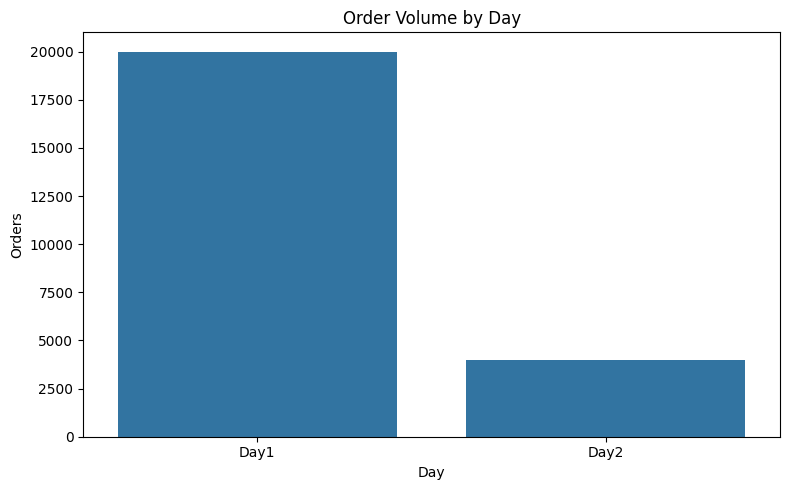

In [103]:
orders_per_day = pd.DataFrame({

    "Day":[
        "Day1",
        "Day2"
    ],

    "Orders":[
        len(orders_df),
        len(orders_day2_df)
    ]

})

plt.figure(figsize=(8,5))

sns.barplot(
    data=orders_per_day,
    x="Day",
    y="Orders"
)

plt.title("Order Volume by Day")

plt.tight_layout()

plt.savefig("charts/order_volume_by_day.png")

plt.show()

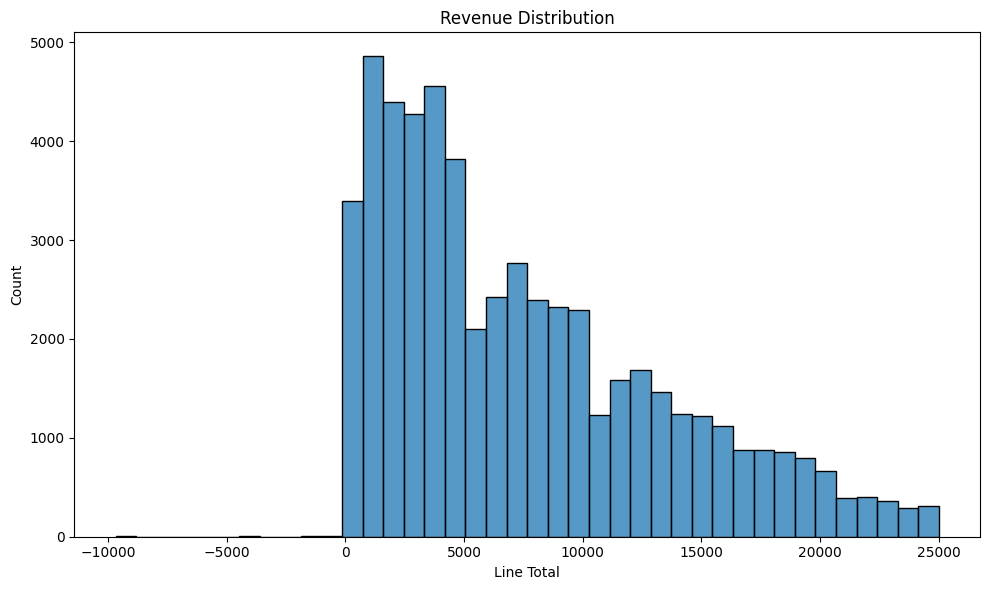

In [104]:
plt.figure(figsize=(10,6))

sns.histplot(
    order_items_df["line_total"],
    bins=40
)

plt.title("Revenue Distribution")

plt.xlabel("Line Total")

plt.tight_layout()

plt.savefig("charts/revenue_distribution.png")

plt.show()

In [105]:
merged = order_items_df.merge(
    products_df,
    on="product_id",
    how="left"
)

In [106]:
category_revenue = merged.groupby(
    "category"
)["line_total"].sum().sort_values(
    ascending=False
).head(10)

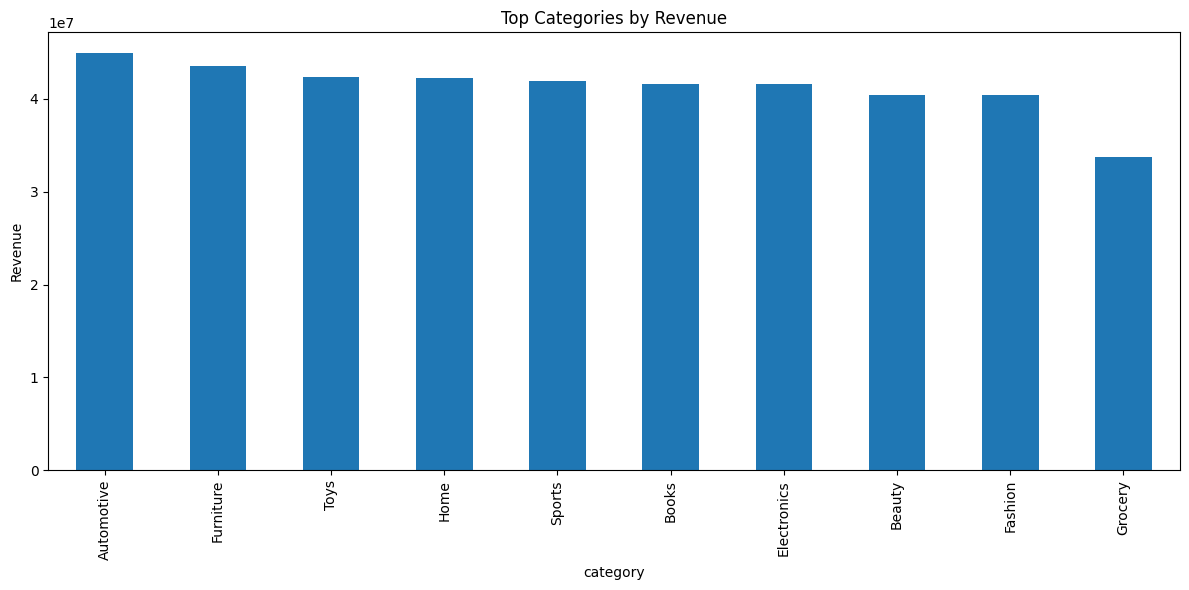

In [107]:
plt.figure(figsize=(12,6))

category_revenue.plot(
    kind="bar"
)

plt.title("Top Categories by Revenue")

plt.ylabel("Revenue")

plt.tight_layout()

plt.savefig(
    "charts/top_categories_revenue.png"
)

plt.show()

In [108]:
datasets = {

    "Customers": customers_df,

    "Products": products_df,

    "Orders Day1": orders_df,

    "Order Items Day1": order_items_df,

    "Orders Day2": orders_day2_df,

    "Order Items Day2": order_items_day2_df

}

null_summary = {}

for name, df in datasets.items():

    null_summary[name] = (

        df.isnull().mean()*100

    )

null_df = pd.DataFrame(null_summary)

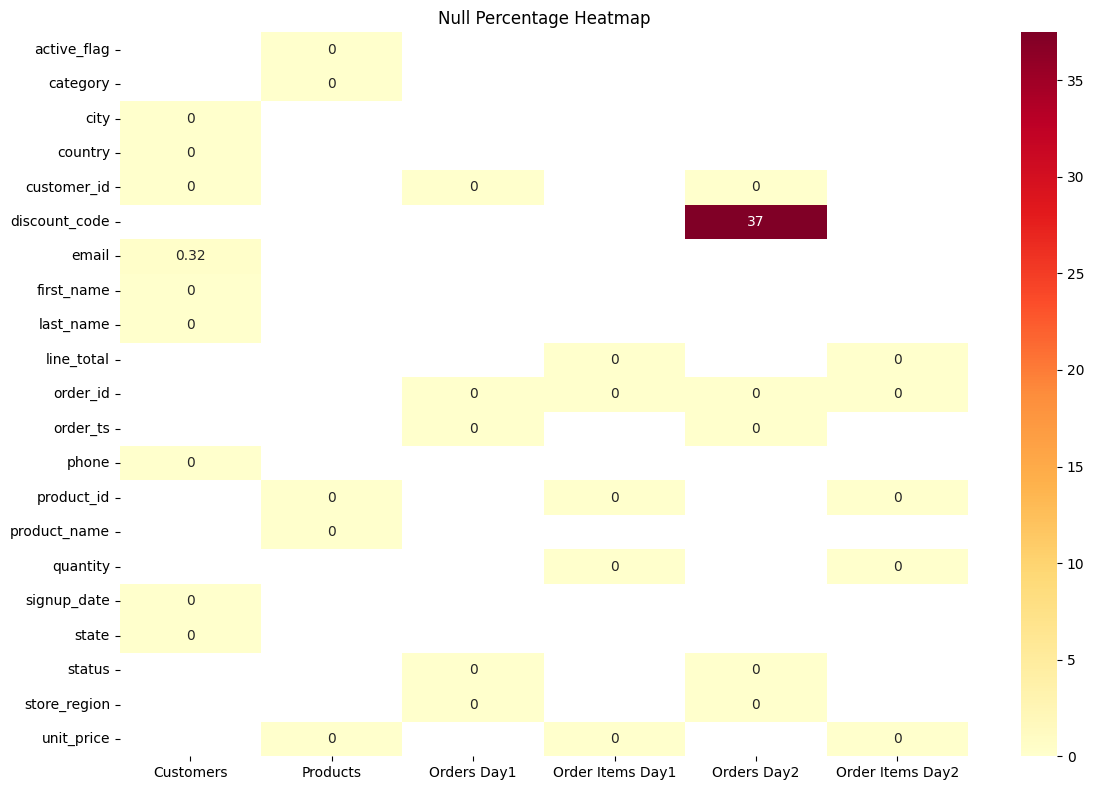

In [109]:
plt.figure(figsize=(12,8))

sns.heatmap(
    null_df,
    annot=True,
    cmap="YlOrRd"
)

plt.title("Null Percentage Heatmap")

plt.tight_layout()

plt.savefig(
    "charts/null_heatmap.png"
)

plt.show()

In [110]:
profile_report = f"""
# RetailFlow Dataset Profiling Report

## Dataset Summary

Customers : {len(customers_df)}

Products : {len(products_df)}

Orders Day1 : {len(orders_df)}

Order Items Day1 : {len(order_items_df)}

Orders Day2 : {len(orders_day2_df)}

Order Items Day2 : {len(order_items_day2_df)}

Clickstream Day1 : {len(clickstream_day1)}

Clickstream Day2 : {len(clickstream_day2)}

---

## Data Quality Issues Introduced

✔ Invalid emails (~2%)

✔ Duplicate customer IDs (~1%)

✔ Invalid product references

✔ Negative quantities

✔ Schema evolution

✔ Missing discount codes

---

## Charts Generated

order_volume_by_day.png

revenue_distribution.png

top_categories_revenue.png

null_heatmap.png
"""

with open(
    "data_profile_report.md",
    "w"
) as file:

    file.write(profile_report)

In [111]:
import os

print("\nGenerated Data")

print(os.listdir("generated_data"))

print("\nCharts")

print(os.listdir("charts"))


Generated Data
['customers.csv', 'products.csv']

Charts
['top_categories_revenue.png', 'null_heatmap.png', 'order_volume_by_day.png', 'revenue_distribution.png']
